# UTA_DIS

## functions and classes:

In [575]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple

from functools import partial
from typing import Any, Tuple
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn.metrics import f1_score


import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
import os

#### models

In [576]:
class CriterionLayerCombine(nn.Module):
    """
    Custom module to combine outputs from all hidden components.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden components.
        min_weight (float, optional): Minimum weight value. Defaults to 0.001.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        min_weight: float = 0.001,
        **kwargs
    ):
        super().__init__()
        self.min_weight = min_weight
        self.weight = nn.Parameter(
            torch.FloatTensor(num_hidden_components, num_criteria)
        )
        self.reset_parameters()

    def reset_parameters(self) -> None:
        """
        Reset the parameters of the module.
        """
        nn.init.uniform_(self.weight, 0.2, 1.0)
        self.weight.data = self.weight.data / torch.sum(self.weight.data)

    def compute_weight(self) -> torch.Tensor:
        """
        Compute the weight value.

        Returns:
            torch.Tensor: Weight value.
        """
        with torch.no_grad():
            self.weight.data[self.weight.data < 0] = self.min_weight
        return self.weight

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor of shape (batch_size, num_hidden_components, num_criteria).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, num_criteria).
        """
        return (input * self.compute_weight()).sum(1)

In [577]:
class CriterionLayerSpread(nn.Module):
    """
    Custom module for spreading the input value to all hidden components.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden components.
        input_range (Tuple[float, float], optional): Range of input values. Defaults to (0, 1).
        normalize_bias (bool, optional): Flag to normalize the bias. Defaults to False.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        input_range: Tuple[float, float] = (0, 1),
        normalize_bias: bool = False,
        **kwargs
    ) -> None:
        super().__init__()
        self.num_criteria = num_criteria
        input_range = (-input_range[0], -input_range[1])
        self.max_bias = max(input_range)
        self.min_bias = min(input_range)
        self.normalize_bias = normalize_bias
        self.bias = nn.Parameter(torch.FloatTensor(num_hidden_components, num_criteria))
        self.weight = nn.Parameter(
            torch.FloatTensor(num_hidden_components, num_criteria)
        )
        self.reset_parameters()
        self.min_w = 0

    def reset_parameters(self) -> None:
        """
        Reset the parameters of the module.
        """
        nn.init.uniform_(self.weight, 1, 10.0)
        nn.init.uniform_(self.bias, self.min_bias, self.max_bias)

    def compute_bias(self) -> torch.Tensor:
        """
        Compute the bias value.

        Returns:
            torch.Tensor: Bias value.
        """
        if self.normalize_bias:
            return torch.clamp(self.bias, self.min_bias, self.max_bias)
        else:
            return self.bias

    def compute_weight(self) -> torch.Tensor:
        """
        Compute the weight value.

        Returns:
            torch.Tensor: Weight value.
        """
        # return torch.clamp(self.weight, 0.0)
        with torch.no_grad():
            self.weight.data[self.weight.data < 0] = self.min_w
        return self.weight

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor of shape (batch_size, num_criteria).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, num_hidden_components, num_criteria).
        """
        x = input.view(-1, 1, self.num_criteria)
        return (x + self.compute_bias()) * self.compute_weight()


In [578]:
class LeakyHardSigmoid(nn.Module):
    """
    Custom module for LeakyHardSigmoid activation function.

    Args:
        slope (float, optional): Slope value for function. Defaults to 0.01.
    """

    def __init__(self, slope: float = 0.01, **kwargs):
        super().__init__()
        self.slope = slope

    def set_slope(self, val: float) -> None:
        """
        Set the slope value for the function.

        Args:
            val (float): Slope value.
        """
        self.slope = val

    def forward(self, input):
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        return F.leaky_relu(1.0 - F.leaky_relu(1 - input, self.slope), self.slope)

In [579]:
class MonotonicLayer(nn.Sequential):
    """
    Custom module for Monotonic layer.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden units.
        slope (float, optional): Slope value for LeakyHardSigmoid. Defaults to 0.01.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        slope: float = 0.01,
        **kwargs
    ):
        super().__init__()
        self.criterion_layer_spread = CriterionLayerSpread(
            num_criteria, num_hidden_components, **kwargs
        )
        self.activation_function = LeakyHardSigmoid(slope=slope, **kwargs)
        self.criterion_layer_combine = CriterionLayerCombine(
            num_criteria, num_hidden_components, **kwargs
        )

    def set_slope(self, val: float) -> None:
        """
        Set the slope value for the LeakyHardSigmoid activation function.

        Args:
            val (float): Slope value.
        """
        self.activation_function.set_slope(val)

    def forward(self, x):
        """
        Forward pass of the module.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, num_criteria).

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, num_criteria).
        """
        for module in self._modules.values():
            x = module(x)
        return x

In [580]:
class Uta(nn.Sequential):
    """
    Custom module for Uta network.

    Args:
        num_criteria (int): Number of criteria.
        num_hidden_components (int): Number of hidden components of monotonic block.
        slope (float, optional): Slope value for LeakyHardSigmoid. Defaults to 0.01.
    """

    def __init__(
        self,
        num_criteria: int,
        num_hidden_components: int,
        slope: float = 0.01,
        **kwargs
    ):
        super().__init__()
        self.monotonic_layer = MonotonicLayer(
            num_criteria, num_hidden_components, slope, **kwargs
        )

    def set_slope(self, val: float) -> None:
        """
        Set the slope value for the LeakyHardSigmoid activation function.

        Args:
            val (float): Slope value.
        """
        self.monotonic_layer.set_slope(val)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            input (torch.Tensor): Input tensor of shape (batch_size,  num_criteria).

        Returns:
            torch.Tensor: Output tensor.
        """
        x = self.monotonic_layer(input)
        return x.sum(1)

In [581]:
class ThresholdLayer(nn.Module):
    """A threshold layer that subtracts a threshold from the input tensor.
    Alternatives from class 1 should have utility greater than the threshold.
    Alternatives from class 0 should have utility less than the threshold.

    """

    def __init__(self, threshold: float = None, requires_grad: bool = True):
        """Initialize the threshold layer.

        Args:
            threshold (float, optional): The threshold value. Defaults to None.
                If None, the threshold is initialized randomly.
            requires_grad (bool, optional): Whether the threshold should be trainable.
                Defaults to True.
        """
        super().__init__()
        if threshold is None:
            self.threshold = nn.Parameter(
                torch.FloatTensor(1).uniform_(0.1, 0.9), requires_grad=requires_grad
            )
        else:
            self.threshold = nn.Parameter(
                torch.FloatTensor([threshold]), requires_grad=requires_grad
            )

    def forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        """Forward pass of the threshold layer.

        Args:
            x (torch.FloatTensor): Input tensor.

        Returns:
            torch.FloatTensor: Output tensor.
        """
        return x - self.threshold

In [582]:
class NormLayer(nn.Module):
    """
    Custom module for min-max normalization layer.

    This normalization layer performs min-max normalization on the input tensor,
    such that if all criteria are equal to 0, the output is 0, and if all criteria
    are equal to 1, the output is 1.
    Additionally, the output is thresholded using a ThresholdLayer with a threshold of 0.5.

    Args:
        method_instance (torch.nn.Module): Instance of the method to be normalized.
        num_criteria (int): Number of criteria.
    """

    def __init__(self, method_instance: torch.nn.Module, num_criteria: int):
        super().__init__()
        self.method_instance = method_instance
        self.num_criteria = num_criteria
        self.thresholdLayer = ThresholdLayer(0.5)

    def set_slope(self, slope: float):
        """
        Set the slope value for the LeakyHardSigmoid activation function.

        Args:
            val (float): Slope value.
        """
        self.method_instance.set_slope(slope)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the module.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        self.out = self.method_instance(input)

        zero_input = torch.zeros(self.num_criteria).view(1, 1, -1).to(self.out.device)
        zero = self.method_instance(zero_input)
        one = self.method_instance(zero_input + 1)

        self.out = (self.out - zero) / (one - zero)
        return self.thresholdLayer(self.out)

#### utils

In [583]:
from functools import partial
from typing import Any, Tuple

import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


class Hook:
    """A class to store a hook for a model."""

    def __init__(self, layer: torch.nn.Module, func: callable):
        """Constructor for the Hook class. Registers a hook on the given model layer.

        Args:
            layer (torch.nn.Module): The layer to register the hook on.
            func (callable): The function to call when the hook is triggered.
        """
        self.hook = layer.register_forward_hook(partial(func, self))

    def remove(self):
        """
        Remove the hook from the model.
        """
        self.hook.remove()

    def __del__(self):
        """Destructor for the Hook class. Removes the hook from the model."""
        self.remove()


def append_output(hook: Hook, mod: torch.nn.Module, input: Any, output: torch.Tensor):
    """Append the output of the layer to the hook."""
    if not hasattr(hook, "stats"):
        hook.stats = []
    if not hasattr(hook, "name"):
        hook.name = mod.__class__.__name__
    data = hook.stats
    data.append(output.data)


def get_simple_input(val: float, num_criteria: int) -> torch.Tensor:
    """
    Creates a simple input tensor with the provided value for all criteria.

    Args:
        val (float): The value to fill the tensor with.
        num_criteria (int): The number of criteria (dimensions) in the tensor.

    Returns:
        torch.Tensor: The created input tensor with shape (1, 1, num_criteria).
    """

    input_tensor = torch.full((1, 1, num_criteria), val, dtype=torch.float)
    return input_tensor.cpu()


class NumpyDataset(Dataset):
    """A class to create a PyTorch dataset from numpy arrays."""

    def __init__(self, data: np.array, targets: np.array):
        """Constructor for the NumpyDataset class.

        Args:
            data (np.array): Input data (features).
            targets (np.array): Target data (labels).
        """
        self.data = torch.Tensor(data)
        self.targets = torch.LongTensor(targets.astype(int))

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Get the item at the given index.

        Args:
            index (int): The index of the item to get.

        Returns:
            tuple(torch.Tensor, torch.Tensor): The input data and target data at the given index.
        """
        x = self.data[index]
        y = self.targets[index]
        return x, y

    def __len__(self) -> int:
        """Get the length of the dataset."""
        return len(self.data)


def CreateDataLoader(data: np.array, targets: np.array) -> DataLoader:
    """Create a DataLoader from the given data and targets.

    Args:
        data (np.array): Input data (features).
        targets (np.array): Target data (labels).

    Returns:
        DataLoader: A DataLoader containing the given data and targets.
    """
    dataset = NumpyDataset(data, targets)
    return DataLoader(dataset, batch_size=len(dataset))


def Regret(output: torch.FloatTensor, target: torch.LongTensor, weight= 1.0) -> torch.FloatTensor:
    """Calculate the regret loss between the output and target tensors.
    For each alternative that is in class 1 the output should be positive, so negative values are penalized.
    For each alternative that is in class 0 the output should be negative, so positive values are penalized.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The regret loss between the output and target tensors.
    """
    return torch.mean(
        F.relu(-(target >= 1).float() * output) + weight * F.relu((target < 1).float() * output)
    )


def Accuracy(output: torch.FloatTensor, target: torch.LongTensor) -> torch.FloatTensor:
    """Calculate the accuracy of the model output compared to the target tensor.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The accuracy of the model output compared to the target tensor.
    """
    return (target == (output > 0) * 1).detach().numpy().mean()


def AUC(output: torch.FloatTensor, target: torch.LongTensor) -> torch.FloatTensor:
    """Calculate the AUC score of the model output compared to the target tensor.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The AUC score of the model output compared to the target tensor.
    """
    return roc_auc_score(target.detach().numpy(), output.detach().numpy())

def F1(output: torch.FloatTensor, target: torch.LongTensor) -> torch.FloatTensor:
    """Calculate the F1 score of the model output compared to the target tensor.

    Args:
        output (torch.FloatTensor): Output tensor from the model.
        target (torch.LongTensor): Target tensor.

    Returns:
        torch.FloatTensor: The F1 score of the model output compared to the target tensor.
    """

    pred = (output > 0).int().detach().numpy()
    true = target.detach().numpy()
    return np.float64(f1_score(true, pred))  

class ScoreTracker:
    def __init__(self):

        self.losses = []
        self.auc_scores = []
        self.acc_scores = []
        self.F1 = []

    def append(self, loss: float, auc: float, acc: float, f1:float) -> None:
        """
        Append the given loss, auc, and acc scores to the respective lists.

        Args:
            loss (float): The loss score to append.
            auc (float): The AUC score to append.
            acc (float): The accuracy score to append.
        """
        self.losses.append(loss)
        self.auc_scores.append(auc)
        self.acc_scores.append(acc)
        self.F1.append(f1)

    def add(self, outputs: torch.FloatTensor, labels: torch.LongTensor) -> None:
        """Calculate and append the loss, auc, and acc scores for the given model outputs
            and ground truth labels.

        Args:
            outputs (torch.FloatTensor): The model outputs.
            labels (torch.LongTensor): The ground truth labels.
        """
        self.losses.append(Regret(outputs, labels).item())
        self.auc_scores.append(AUC(outputs, labels).item())
        self.acc_scores.append(Accuracy(outputs, labels).item())
        self.F1.append(F1(outputs, labels).item())


def Train(
    model: torch.nn.Module,
    train_dataloader: DataLoader,
    test_dataloader: DataLoader,
    path: str,
    lr: float = 0.01,
    epoch_nr: int = 200,
    slope_decrease: bool = False,
    weight = 1.0,
) -> Tuple[float, float, ScoreTracker, ScoreTracker]:
    """Train the given model using the given training and test dataloaders.

    Args:
        model (torch.nn.Module): The model to train.
        train_dataloader (DataLoader): The dataloader containing the training data.
        test_dataloader (DataLoader): The dataloader containing the test data.
        path (str): The path to save the model.
        lr (float, optional): The learning rate for the optimizer. Defaults to 0.01.
        epoch_nr (int, optional): The number of epochs to train the model. Defaults to 200.
        slope_decrease (bool, optional): Whether to decrease the slope of the leaky hard sigmoid.

    Returns:
        tuple(float, float, ScoreTracker, ScoreTracker): A tuple containing the best accuracy,
            best AUC score, training stats, and test stats.
    """

    optimizer = optim.AdamW(
        model.parameters(), lr=lr, betas=(0.9, 0.99), weight_decay=0.01
    )
    # Add a learninge rate scheduler to the optimizer
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(train_dataloader), epochs=epoch_nr
    )
    best_acc = 0.0
    best_auc = 0.0
    best_F1 = 0.0
    stats_train = ScoreTracker()
    stats_test = ScoreTracker()
    # Decrease the slope of the leaky hard sigmoid activation function in each epoch
    slopes = np.linspace(0.01, 0.003, epoch_nr)
    for epoch in tqdm(range(epoch_nr)):
        if slope_decrease:
            model.set_slope(slopes[epoch])
        for _, data in enumerate(train_dataloader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = Regret(outputs, labels, weight)
            loss.backward()
            optimizer.step()
            scheduler.step()
            acc = Accuracy(outputs, labels)
            auc = AUC(outputs, labels)
            F1_score = F1(outputs, labels)
            stats_train.append(loss.item(), auc.item(), acc.item(), F1_score.item())
        with torch.no_grad():
            for _, data in enumerate(test_dataloader, 0):
                inputs, labels = data
                outputs = model(inputs)
                stats_test.add(outputs, labels)

        # Save the model if the accuracy is better than the previous best
        if acc > best_acc:
            best_acc = acc
            best_auc = auc
            best_F1 = F1_score

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                },
                path,
            )

    return (
        best_acc,
        best_auc,
        best_F1,
        stats_train,
        stats_test,
    )

## main

### model loading:

In [ ]:
# Load data, split into train and test sets and create dataloaders
os.makedirs("models", exist_ok=True)

data_path = os.path.join("dataset_refining", "german_credit_data_with_risk.csv")
data = pd.read_csv(data_path, header=0)
data['Checking account'] = data['Checking account'].fillna(3)
data['Saving accounts'] = data['Saving accounts'].fillna(0)
data.drop(columns= ['Sex', ], inplace=True) # purpose is categorical and judging by sex should be not relevant

data.replace({'Checking account': {'little': 1, 'moderate': 2, 'rich': 3}}, inplace=True)
data.replace({'Saving accounts':{'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}}, inplace=True)
# data.replace({'Housing': {'own': 2, 'rent': 1, 'free': 0}}, inplace=True)
# data.replace({'Sex' : {'male': 0, 'female': 1}}, inplace=True)
data.drop(columns=[ 'Housing', 'Job'], inplace=True) 
data['credit_risk'] = data['credit_risk'].map({1: 1, 2: 0})
labels_map = {1: "low risk", 0: "high risk"}
data['Credit amount'] = -data['Credit amount']

purpose_map = {
    "radio/TV": 0,
    "car": 0,
    "vacation/others": 0,
    "furniture/equipment": 1,
    "repairs": 1,
    'domestic appliances': 1,
    "education": 2,
    "business": 2
}
data["Purpose"] = data["Purpose"].map(purpose_map)
data["Duration"] = -data["Duration"]

'''Age (numeric)
Sex (text: male, female)
Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)
Housing (text: own, rent, or free)
Saving accounts (text - little, moderate, quite rich, rich)
Checking account (numeric, in DM - Deutsch Mark)
Credit amount (numeric, in DM)
Duration (numeric, in month)'''


C:\Users\onece\AppData\Local\Temp\ipykernel_540\2572666040.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Checking account': {'little': 1, 'moderate': 2, 'rich': 3}}, inplace=True)
C:\Users\onece\AppData\Local\Temp\ipykernel_540\2572666040.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({'Saving accounts':{'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}}, inplace=True)


'Age (numeric)\nSex (text: male, female)\nJob (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)\nHousing (text: own, rent, or free)\nSaving accounts (text - little, moderate, quite rich, rich)\nChecking account (numeric, in DM - Deutsch Mark)\nCredit amount (numeric, in DM)\nDuration (numeric, in month)'

In [585]:
data

,Age,Saving accounts,Checking account,Credit amount,Duration,Purpose,credit_risk
0,67,0,1,-1169,-6,0,1
1,22,0,2,-5951,-48,0,0
2,49,0,3,-2096,-12,2,1
3,45,0,1,-7882,-42,1,1
4,53,0,1,-4870,-24,0,0
...,...,...,...,...,...,...,...
995,31,0,3,-1736,-12,1,1
996,40,0,1,-3857,-30,0,1
997,38,0,3,-804,-12,0,1
998,23,0,1,-1845,-45,0,0


In [586]:
from sklearn.preprocessing import MinMaxScaler

num_criteria = 6
data_input = data.iloc[:, :num_criteria]
columns = data.columns
data_target = data[columns[num_criteria]]

data_input = data.iloc[:, :num_criteria].values
data_target = data['credit_risk'].values

# Normalize to [0, 1]
scaler = MinMaxScaler()
data_input = scaler.fit_transform(data_input.reshape(-1, num_criteria))
data_input = data_input.reshape(-1, 1, num_criteria)


X_train, X_test, y_train, y_test = train_test_split(
    data_input, data_target, test_size=0.2, random_state=42
)

train_dataloader = CreateDataLoader(X_train, y_train)
test_dataloader = CreateDataLoader(X_test, y_test)

In [587]:
SAVE_PATH = "models/cnn_utadis_model.pth"
# Create model and train
uta = Uta(num_criteria, 30)
model = NormLayer(uta, num_criteria)
weight_pos = (y_train == 0).sum() / (y_train == 1).sum()
(
    best_acc,
    best_auc,
    best_F1,
    stats_train,
    stats_test,
) = Train(model, train_dataloader, test_dataloader, SAVE_PATH,epoch_nr=500,lr =0.0001,slope_decrease=True, weight = weight_pos)

100%|██████████| 500/500 [00:14<00:00, 34.55it/s]


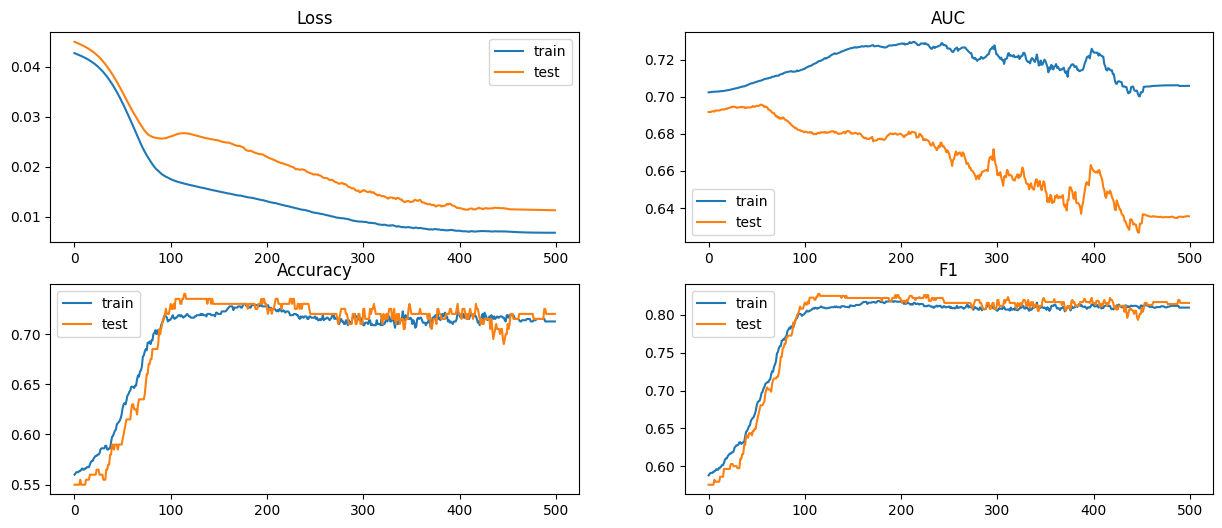

In [588]:
# Plot results
fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(2,2,1)
ax.plot(stats_train.losses,label='train')
ax.plot(stats_test.losses,label='test')
ax.set_title('Loss')
ax.legend()

ax = fig.add_subplot(2,2,2)
ax.plot(stats_train.auc_scores,label='train')
ax.plot(stats_test.auc_scores,label='test')
ax.set_title('AUC')
ax.legend()

ax = fig.add_subplot(2,2,3)
ax.plot(stats_train.acc_scores,label='train')
ax.plot(stats_test.acc_scores,label='test')
ax.set_title('Accuracy')
ax.legend()

ax = fig.add_subplot(2,2,4)
ax.plot(stats_train.F1,label='train')
ax.plot(stats_test.F1,label='test')
ax.set_title('F1')
ax.legend()

In [589]:
# Load model from checkpoint
checkpoint = torch.load(SAVE_PATH)
model.load_state_dict(checkpoint["model_state_dict"])

C:\Users\onece\AppData\Local\Temp\ipykernel_540\3460310204.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_PATH)


<All keys matched successfully>

In [590]:


hook = Hook(model.method_instance.monotonic_layer, append_output)
xs = []
with torch.no_grad():
    for i in range(201):
        val = i / 200.0
        x = get_simple_input(val,num_criteria)
        xs.append(val)
        model(x)

outs = np.array(torch.stack(hook.stats)[:, 0].detach().cpu())
# We take every third value becouse the rest are from the normalization layer: velues for 0 and 1
outs = outs[::3] - outs[::3][0]
# Normalize the outputs to get proper weights of the criteria
outs = outs / outs[-1].sum()

In [591]:
with torch.no_grad():
    X_test_tensor = torch.Tensor(X_test).squeeze(1)
    outputs = model(X_test_tensor)   # output = utility - 0.5
    predictions = (outputs > 0)      # utility > 0.5 → class 1 (good)
    predictions = predictions.cpu().numpy()

In [595]:
predictions[:20], y_test[:20]

(array([False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True, False, False,  True,  True,  True,
        False,  True]),
 array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1],
       dtype=int64))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.23      0.64      0.34        59
           1       0.43      0.11      0.18       141

    accuracy                           0.27       200
   macro avg       0.33      0.38      0.26       200
weighted avg       0.37      0.27      0.23       200



criterion Age:


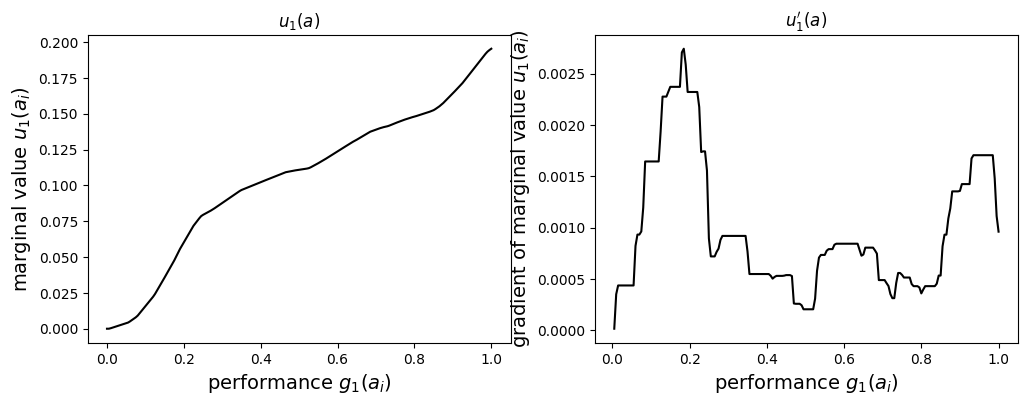

criterion Saving accounts:


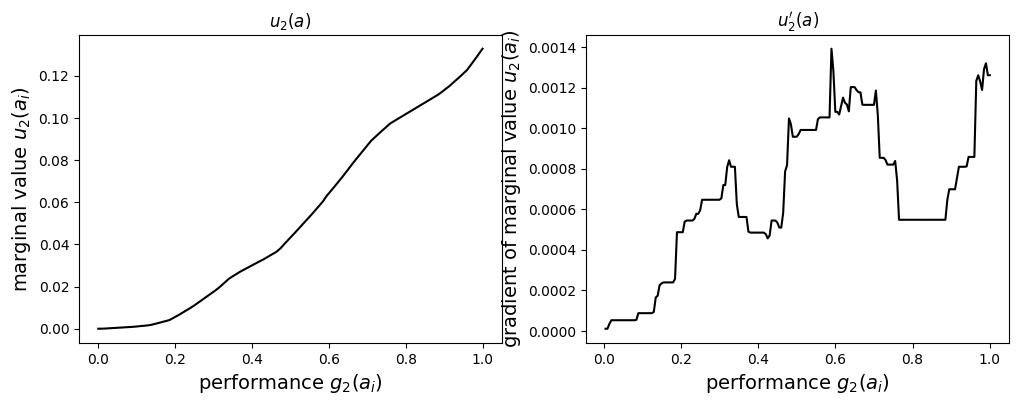

criterion Checking account:


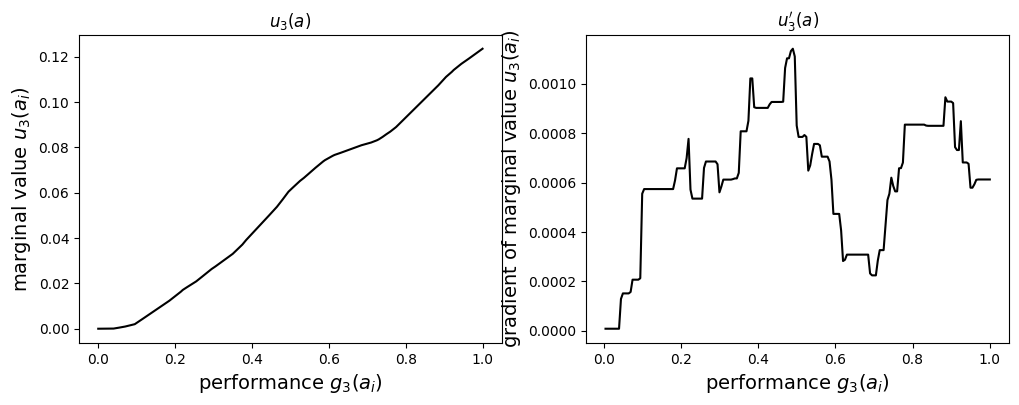

criterion Credit amount:


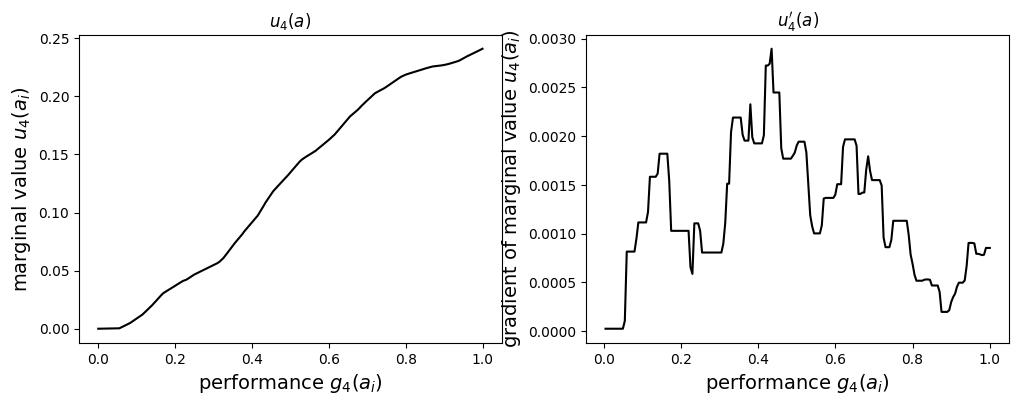

criterion Duration:


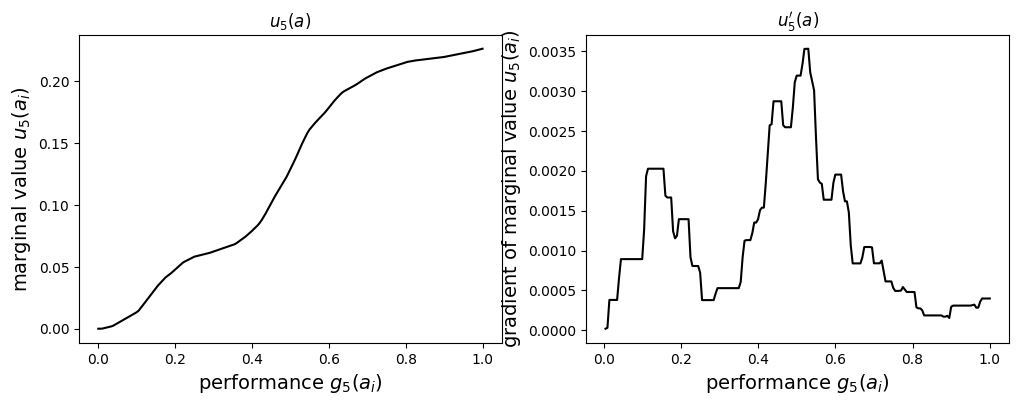

criterion Purpose:


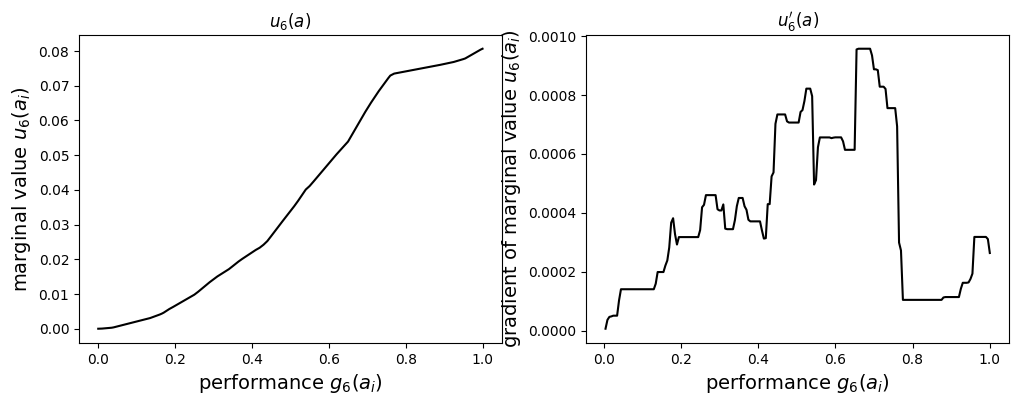

In [594]:
for i in range(num_criteria):
    criterion_number = i + 1
    print(f"criterion {data.columns[i]}:")

    fig = plt.figure(figsize=(12,4))  
    ax = fig.add_subplot(121)
    ax.set_title(f'$u_{criterion_number}(a)$')
    ax.plot(xs, outs[:, i], color="black")
    ax.set_ylabel(f"marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)

    ax = fig.add_subplot(1,2,2)
    ax.set_title(f"$u_{criterion_number}'(a)$")
    ax.plot(xs[1:], outs[1:, i]-outs[:-1, i], color="black")
    ax.set_ylabel(f"gradient of marginal value $u_{criterion_number}(a_i)$", fontsize=14)
    ax.set_xlabel(f"performance $g_{criterion_number}(a_i)$", fontsize=14)
    plt.show()

#todo 

Wagi kryteriów (bar plot z outs[-1] — udział każdego kryterium w łącznej użyteczności)

Confusion matrix

ROC curve

• All presented values should be rounded to a maximum of 4 decimal places.

 A brief summary taking into account the conclusions of the following analyses

In [601]:
outs.shape

(201, 6)

Index(['Age', 'Saving accounts', 'Checking account', 'Credit amount',
       'Duration', 'Purpose', 'credit_risk'],
      dtype='object')

#### weights for categories

           category    weight
0               Age  0.195420
1   Saving accounts  0.132827
2  Checking account  0.123547
3     Credit amount  0.241051
4          Duration  0.226493
5           Purpose  0.080663


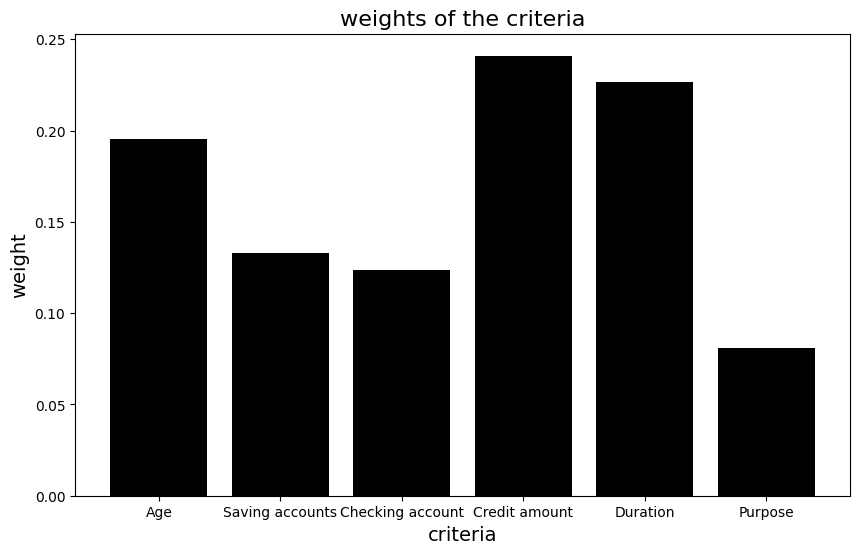

In [620]:
names = data.columns[:num_criteria]
weights = []
for i in range(num_criteria):
    weights.append(outs[-1][i]) 
df_weights = pd.DataFrame({"category": names, "weight" : weights})
print(df_weights)
#barplot of the weights
plt.figure(figsize=(10,6))
plt.bar(df_weights["category"], df_weights["weight"], color="black")
plt.xlabel("criteria", fontsize=14)
plt.ylabel("weight", fontsize=14)
plt.title("weights of the criteria", fontsize=16)
plt.show()

#### confusion matrix

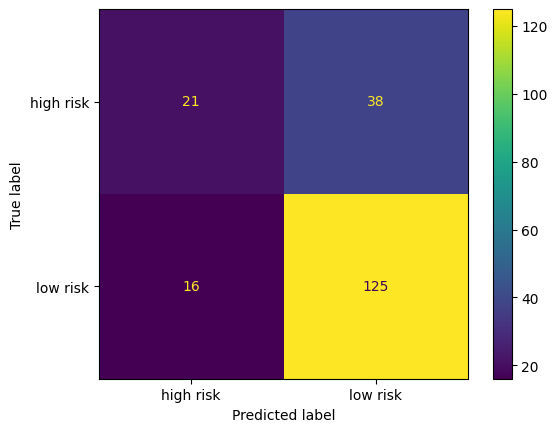

In [619]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=[0, 1],
    display_labels=[labels_map[0], labels_map[1]]
)

#### AUC curve


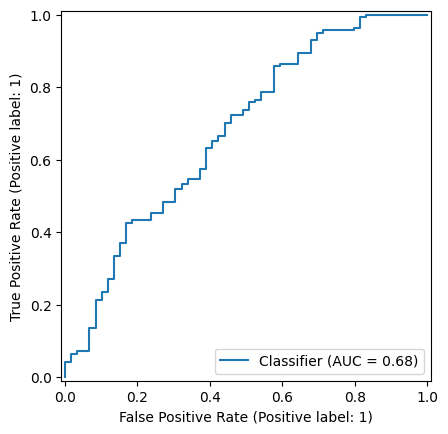

In [621]:
#### AUC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, outputs.cpu().numpy(), pos_label=1)

#### breif summary

## 2.1